# Word Embeddings: Visualization & Analysis

This notebook trains Word2Vec embeddings on both datasets, then reduces them to 2D using **PCA** and **t-SNE** to reveal semantic structure — and contrasts what classical (BoW/TF-IDF) vectors *cannot* capture.

In [1]:
import sys
sys.path.insert(0, '..')  # make src/ importable from notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from omegaconf import OmegaConf

from src.data.ingest import load_data
from src.features.preprocess import TextNormalizer
from src.features.embeddings import train_embeddings, save_embeddings, load_embeddings, most_similar

print('Imports OK')

Imports OK


## 1. Load & Preprocess Amazon Data

In [2]:
# Load configs
dataset_cfg  = OmegaConf.load('../conf/dataset/amazon.yaml')
preproc_cfg  = OmegaConf.load('../conf/preprocess/amazon.yaml')
split_cfg    = OmegaConf.load('../conf/split/default.yaml')

cfg = OmegaConf.create({'dataset': dataset_cfg, 'preprocess': preproc_cfg, 'split': split_cfg})

df = load_data(cfg)
print(f'Loaded {len(df):,} rows  |  label dist:\n{df["target"].value_counts()}')
     

Loading dataset from: D:\ITI DS\NLP\NLP-Sentiment-Analysis\data\raw\Reviews.csv
Loaded 525,814 rows  |  label dist:
target
1    443777
0     82037
Name: count, dtype: int64


In [3]:
# Sample for speed — embeddings train on 50k docs
SAMPLE = 50_000
df_sample = df.sample(n=min(SAMPLE, len(df)), random_state=42)

normalizer = TextNormalizer(preproc_cfg)
cleaned = normalizer.transform(df_sample['raw_text'])
labels  = df_sample['target'].values
print(f'Preprocessed {len(cleaned):,} texts')

Running text normalization pipeline...
Preprocessed 50,000 texts


## 2. Train Word2Vec

In [4]:
w2v_model = train_embeddings(
    cleaned,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    epochs=5,
)
save_embeddings(w2v_model, '../models/amazon_word2vec.model')
print(f'Vocabulary size: {len(w2v_model.wv):,}')

Training Word2Vec on 50,000 documents (vector_size=100, window=5, epochs=5)...
Word2Vec model saved to: ../models/amazon_word2vec.model
Vocabulary size: 12,584


## 3. Semantic Nearest Neighbours

In [5]:
seed_words = ['delicious', 'terrible', 'fresh', 'awful', 'love', 'hate']

for word in seed_words:
    neighbours = most_similar(w2v_model, word, n=5)
    neighbour_str = ', '.join(f"{w} ({s:.2f})" for w, s in neighbours)
    print(f'{word:12s} → {neighbour_str}')

delicious    → yummy (0.81), tasty (0.75), wonderful (0.68), satisfying (0.67), fabulous (0.67)
terrible     → horrible (0.88), awful (0.87), disgusting (0.86), nasty (0.77), gross (0.75)
fresh        → fresher (0.54), plump (0.54), packed (0.50), packaged (0.50), sealed (0.49)
awful        → disgusting (0.89), horrible (0.88), terrible (0.87), weird (0.84), nasty (0.82)
love         → enjoys (0.64), loved (0.61), adore (0.60), fantastic (0.59), awesome (0.55)
hate         → dislike (0.73), hated (0.59), honestly (0.56), gross (0.55), like (0.55)


## 4. PCA Visualization — Sentiment Word Clusters

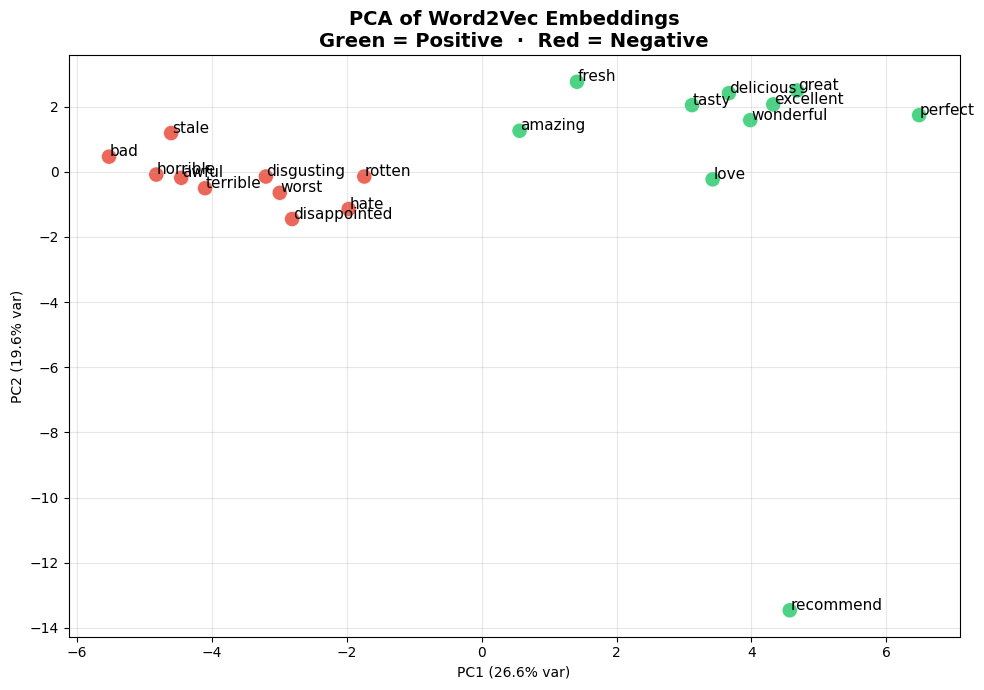

PCA plot saved to reports/figures/pca_embeddings.png


In [6]:
POSITIVE_WORDS = ['delicious', 'amazing', 'love', 'fresh', 'great', 'excellent',
                  'wonderful', 'perfect', 'recommend', 'tasty']
NEGATIVE_WORDS = ['terrible', 'awful', 'hate', 'disgusting', 'worst', 'horrible',
                  'bad', 'rotten', 'stale', 'disappointed']

# Filter to words that are in the vocabulary
pos_in_vocab = [w for w in POSITIVE_WORDS if w in w2v_model.wv]
neg_in_vocab = [w for w in NEGATIVE_WORDS if w in w2v_model.wv]

words  = pos_in_vocab + neg_in_vocab
colors = ['#2ecc71'] * len(pos_in_vocab) + ['#e74c3c'] * len(neg_in_vocab)
vecs   = np.array([w2v_model.wv[w] for w in words])

# PCA to 2D
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vecs)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=120, alpha=0.85, edgecolors='white', linewidths=0.5)

for i, word in enumerate(words):
    ax.annotate(word, (coords[i, 0] + 0.01, coords[i, 1] + 0.01), fontsize=11)

ax.set_title('PCA of Word2Vec Embeddings\nGreen = Positive  ·  Red = Negative', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/pca_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print('PCA plot saved to reports/figures/pca_embeddings.png')

## 5. t-SNE Visualization — 500 Random Words

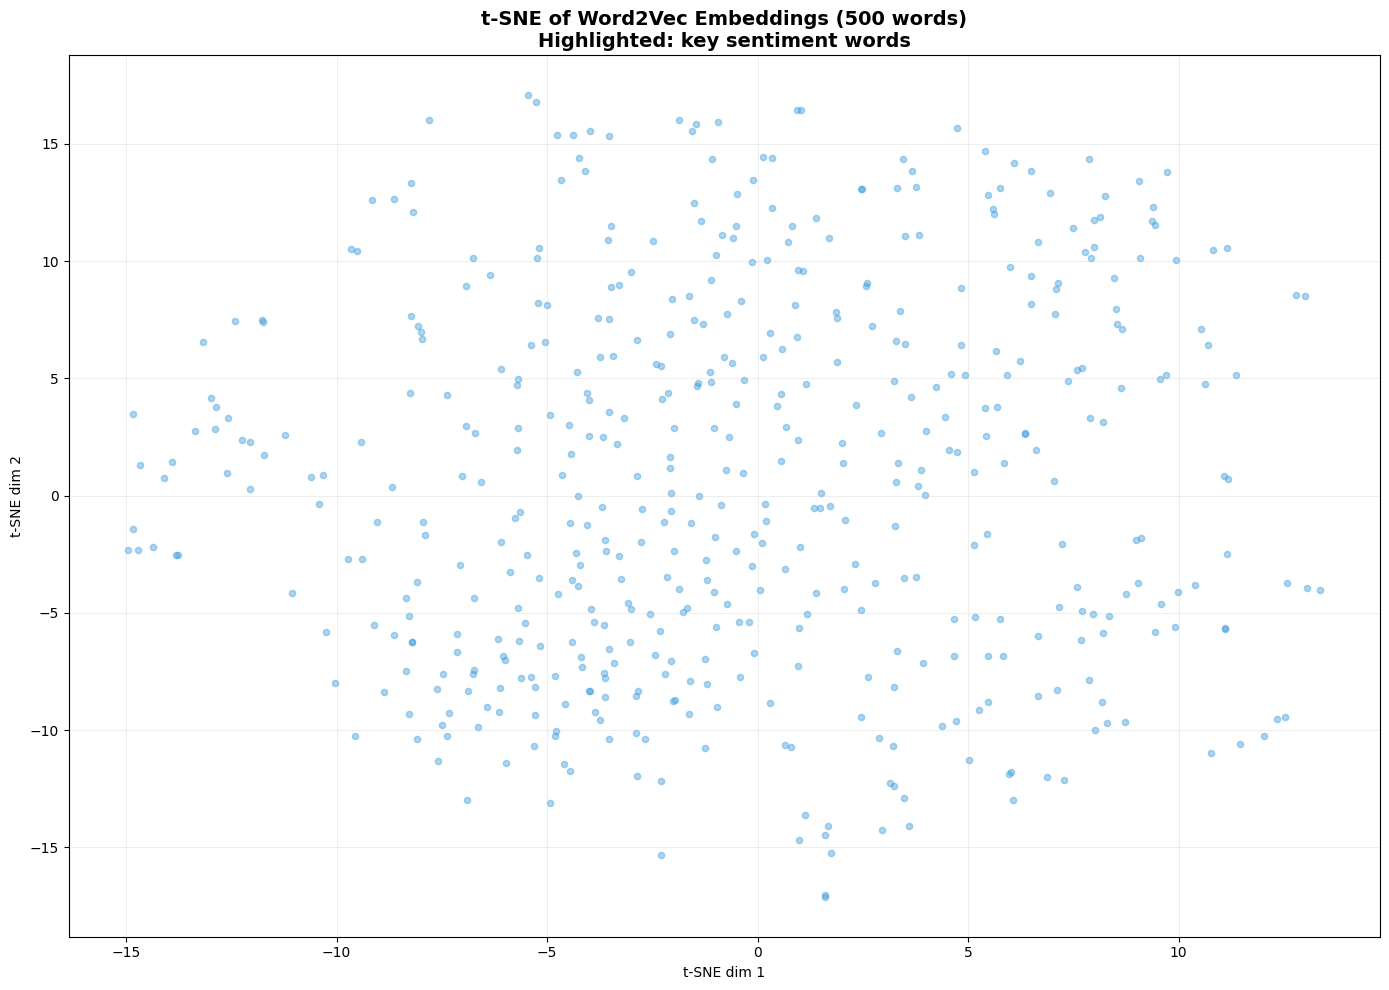

t-SNE plot saved to reports/figures/tsne_embeddings.png


In [8]:
# Sample 500 words from the vocabulary
np.random.seed(42)
vocab_words = list(w2v_model.wv.key_to_index.keys())
sample_words = np.random.choice(vocab_words, size=min(500, len(vocab_words)), replace=False)
sample_vecs  = np.array([w2v_model.wv[w] for w in sample_words])

# Reduce with t-SNE
tsne   = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
tsne_coords = tsne.fit_transform(sample_vecs)

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(tsne_coords[:, 0], tsne_coords[:, 1], alpha=0.4, s=20, color='#3498db')

# Annotate a subset of interesting words
highlight = {'delicious', 'terrible', 'love', 'hate', 'fresh', 'awful',
             'amazing', 'horrible', 'great', 'worst', 'recommend', 'disgusting'}
for i, word in enumerate(sample_words):
    if word in highlight:
        color = '#27ae60' if word in POSITIVE_WORDS else '#e74c3c'
        ax.annotate(word, (tsne_coords[i, 0], tsne_coords[i, 1]),
                    fontsize=11, color=color, fontweight='bold')

ax.set_title('t-SNE of Word2Vec Embeddings (500 words)\nHighlighted: key sentiment words', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('../reports/figures/tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print('t-SNE plot saved to reports/figures/tsne_embeddings.png')

## 6. What Classical Vectors Cannot Capture

| Property | BoW / TF-IDF | Word2Vec |
|----------|-------------|----------|
| Semantic similarity | ❌ treats 'good' and 'great' as unrelated | ✅ close vectors |
| Word analogies | ❌ | ✅ king − man + woman ≈ queen |
| Out-of-vocabulary | ❌ zero vector | ❌ (also OOV) |
| Context sensitivity | ❌ | ❌ (static) — need BERT for that |
| Interpretability | ✅ feature = word | ❌ 100-dim dense |
| Training speed | ✅ fast | 🟡 seconds–minutes |

In [9]:
# Word analogy demo: good - bad + terrible ≈ ?
try:
    result = w2v_model.wv.most_similar(positive=['good', 'terrible'], negative=['bad'], topn=5)
    print('good − bad + terrible ≈', result)
except KeyError as e:
    print(f'Word not in vocabulary: {e}')

good − bad + terrible ≈ [('fantastic', 0.6278789043426514), ('excellent', 0.6261261105537415), ('awesome', 0.6067594289779663), ('amazing', 0.6028245091438293), ('exceptional', 0.6020894646644592)]
